# 1_data_prep_Barbie
streamlined notebook showing the current routine of grid loading and trimming before we save in the form used for training and testing pitchforks

- duplicated for different grids
- upstream of sandbox files used to test new data augmentations and make plots - do not mess around with grids here!

In [1]:
#misc
import pandas as pd
import numpy as np
import h5py
import random
import time
import os

#plotting
import matplotlib.pyplot as plt
from cmcrameri import cm

## load in the grid:
 - Check headers against BASTA docs here: https://basta.readthedocs.io/en/latest/controls_parameters.html

In [2]:
barbie_h5 = h5py.File("/home/oxs235/datastorage/repos_data/ojscutt/pitchfork/data/Garstec_AS09_barbieMS.hdf5", 'r')

print(list(barbie_h5['grid/tracks/track0001']))

['BP_GAIA', 'FeH', 'FeHini', 'G_GAIA', 'LPhot', 'MMaxNucE', 'Mbcz', 'Mcore', 'McoreX', 'MeH', 'MeHini', 'PS', 'RMaxNucE', 'RP_GAIA', 'Rbcz', 'Rcore', 'RcoreX', 'TAMS', 'Teff', 'ZAMSLPhot', 'ZAMSTeff', 'age', 'alphaFe', 'alphaMLT', 'd02fit', 'd02mean', 'dage', 'dif', 'dnuAsf', 'dnuSer', 'dnufit', 'dnufitMos12', 'dnuscal', 'epsfit', 'epsfitMos12', 'errflagSer', 'eta', 'fdnuAsf', 'fdnuSer', 'gcut', 'logg', 'massfin', 'massini', 'modnum', 'name', 'numax', 'numaxAsf', 'nummodSer', 'osc', 'osckey', 'ove', 'radPhot', 'radTot', 'rho', 'rhocen', 'tau0', 'taubcz', 'tauhe', 'volume_weight', 'xcen', 'xini', 'xsur', 'ycen', 'yini', 'ysur', 'zcen', 'zini', 'zsur']


119


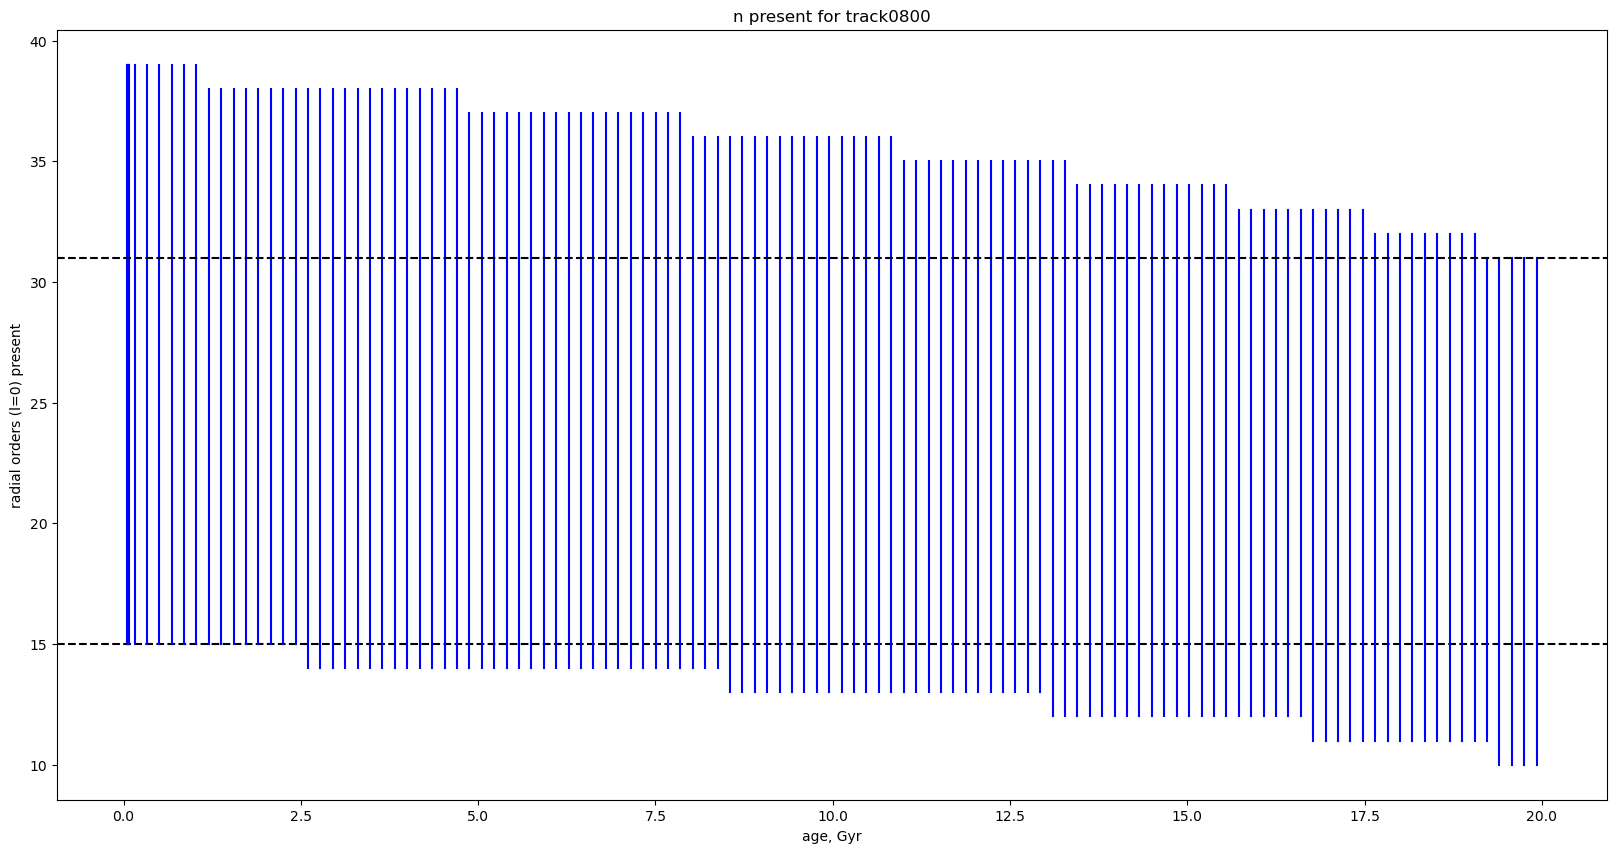

In [3]:
def n_present_plot(grid, track_id, max_age=np.inf):
    plt.figure(figsize=(20,10))
    
    points = np.array(grid['grid/tracks/track'+track_id+'/age'])[np.where(np.array(grid['grid/tracks/track'+track_id+'/age'])<=max_age)[0]]
    first_point = points[0]
    last_point = points[-1]
    
    i = 0
    for point in points:
        osckeys = grid['grid/tracks/track'+track_id+'/osckey']
        n_upper = osckeys[i][1][np.where(osckeys[i][0] == 0)[0][-1]]
        n_lower = osckeys[i][1][np.where(osckeys[i][0] == 0)[0][0]]

        plt.plot(np.full(2,point)/1000, np.array([n_upper, n_lower]), color='blue')
        
        if point == first_point:
            plt.axhline(n_lower, linestyle='dashed', color='black')
        elif point == last_point:
            plt.axhline(n_upper, linestyle='dashed', color='black')
        i+=1

    plt.xlabel('age, Gyr')
    plt.ylabel('radial orders (l=0) present')
    plt.title('n present for track'+track_id)
    print(i)
    
n_present_plot(barbie_h5, '0800')
#print(barbie_h5['grid/tracks/track0001/osckey'][0][1][np.where(barbie_h5['grid/tracks/track0001/osckey'][0][0] == 0)])
#print(barbie_h5['grid/tracks/track0001/osc'][0][0][np.where(barbie_h5['grid/tracks/track0001/osckey'][0][0] == 0)])

119


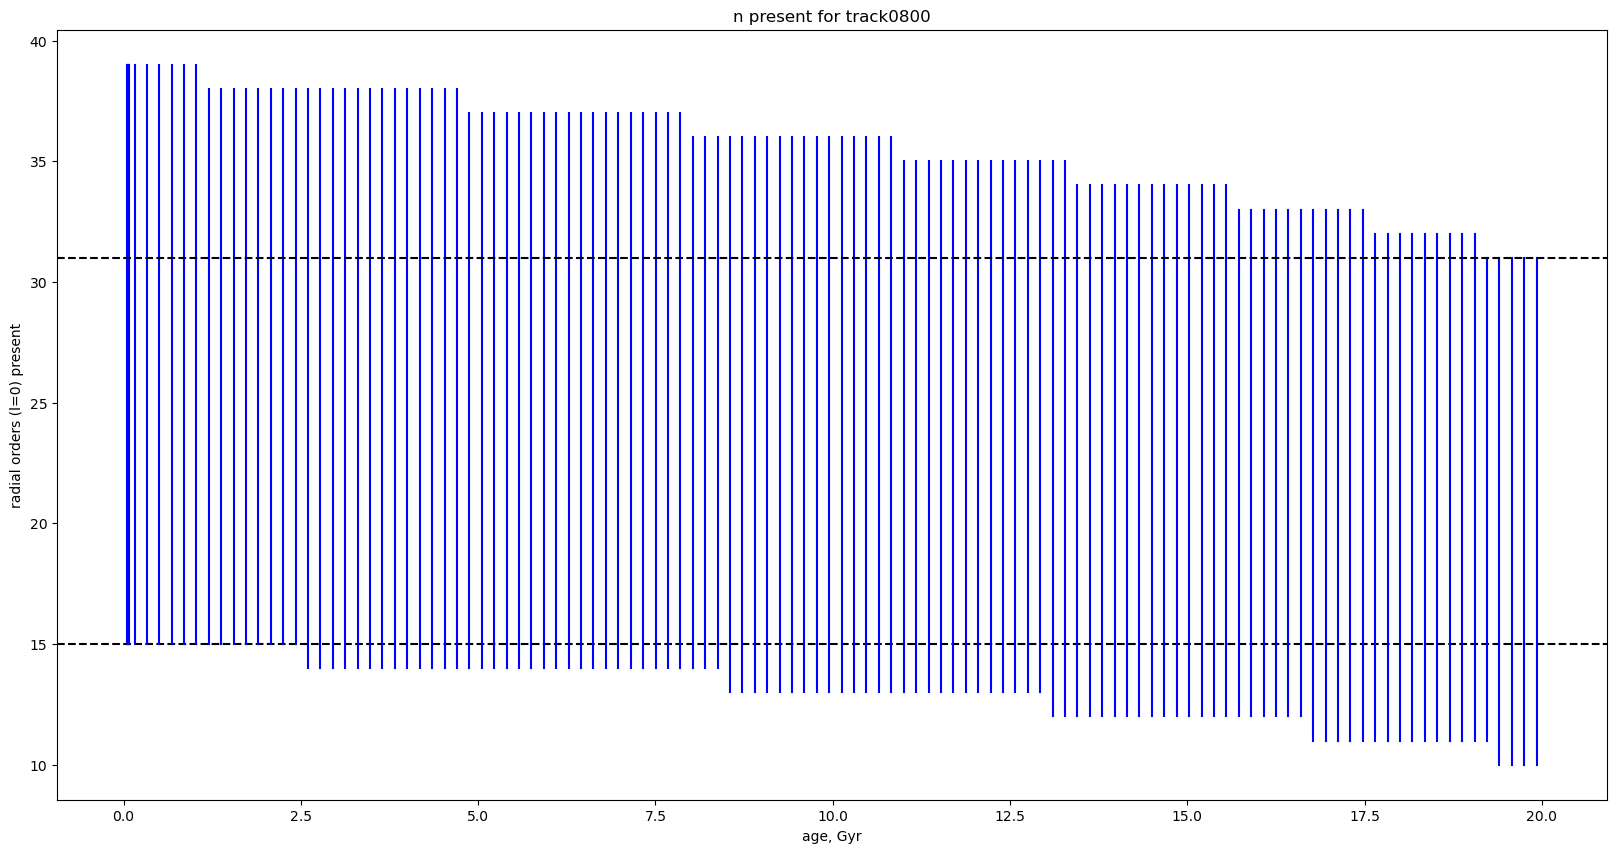

In [17]:
def n_padded_plot(grid, track_id, max_age=np.inf):
    plt.figure(figsize=(20,10))

    track = grid['grid/tracks/track'+track_id]
    age = track['age']

    points = np.array(age)[np.where(np.array(age)<=max_age)[0]]
    first_point = points[0]
    last_point = points[-1]
    
    osckeys = track['osckey']
    dnufits = track['dnufit']
    
    i = 0
    for point in points:
        n_vals = osckeys[i][1][np.where(osckeys[i][0] == 0)[0]]
        n_upper = n_vals[-1]
        n_lower = n_vals[0]

        plt.plot(np.full(2,point)/1000, np.array([n_upper, n_lower]), color='blue')

        if n_upper < 25:
            dnufit = dnufits[i]
            



        
        
        if point == first_point:
            plt.axhline(n_lower, linestyle='dashed', color='black')
        elif point == last_point:
            plt.axhline(n_upper, linestyle='dashed', color='black')
        i+=1

    plt.xlabel('age, Gyr')
    plt.ylabel('radial orders (l=0) present')
    plt.title('n present for track'+track_id)
    print(i)
    
n_padded_plot(barbie_h5, '0800')
#print(barbie_h5['grid/tracks/track0001/osckey'][0][1][np.where(barbie_h5['grid/tracks/track0001/osckey'][0][0] == 0)])
#print(barbie_h5['grid/tracks/track0001/osc'][0][0][np.where(barbie_h5['grid/tracks/track0001/osckey'][0][0] == 0)])